<a href="https://colab.research.google.com/github/muratal49/DroneStabilization_using_GNNs_DRL/blob/main/drone_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## INITIALIZE NOTEBOOK:

In [1]:
#connect to drive:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Drone\ Stabilization\ GNN+Deep\ RL




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Drone Stabilization GNN+Deep RL


In [2]:
#import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
# MODELS:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader, Dataset
import torch.nn.functional as F


In [11]:
# df=pd.read_csv('drone_scenarios.csv',sep=';')

In [13]:
# df.head(2)

In [17]:
#listing those which have greater than 1 less than 10:
# cat_cols=df.columns[(df.nunique() > 1) & (df.nunique() < 10)]
# cat_cols

In [18]:
# single_state=df.columns[(df.nunique()==1)]
# single_state

In [19]:
#dropping single state cols:
# df1=df.drop(columns=single_state,axis=1,inplace=True)

In [20]:
# df.columns

In [2]:
#plotting: plot for each flight (1 to 20) the change in the wind speed:
# columns_plot=df.columns[3:]

# flights_to_plot = [1, 2]  # or use df['flight'].unique()[:2]
# plt.figure(figsize=(20, 5))

# for col in columns_plot:
#     for idx, flight_id in enumerate(flights_to_plot, 1):
#       plt.subplot(1, 2, idx)
#       plt.plot(df[df['flight'] == flight_id][col])
#       plt.title(f'Flight {flight_id} - {col}')
#       plt.xlabel('Time Step')
#       plt.ylabel(f'{col}')

#     plt.tight_layout()
#     plt.show()

# Modeling GNN:
- normalizing data
- clearing data


In [22]:
params=pd.read_csv('parameters.csv')

In [23]:
params=params.drop(columns=['date',	'local_time','route'])


In [24]:
params.head(2)

,flight,speed,payload,altitude
0,1,4.0,0.0,25
1,2,4.0,0.0,50


In [25]:
#Sub-sampling:
# Define desired payload and speed values
payloads = [0, 250, 500]
speeds = [4, 6, 8, 10, 12]

# Sample per (payload, speed) combo
selected_rows = []
for p in payloads:
    for s in speeds:
        group = params[(params['payload'] == p) & (params['speed'] == s)]
        if len(group) >= 3:
            sample = group.sample(n=3, random_state=42)
        elif len(group) > 0:
            sample = group
        else:
            continue
        selected_rows.append(sample)

# Combine all selected flights
subset = pd.concat(selected_rows, ignore_index=True)
subset.to_csv("selected_flights.csv", index=False)

selected_ids = subset['flight'].tolist()
len(selected_ids)

45

In [26]:
flight_dfs = []
for flight_id in selected_ids:
    df = pd.read_csv(f'flights/{flight_id}.csv')
    df['flight_id'] = flight_id

    # Add flight-level info
    meta = subset[subset['flight'] == flight_id].iloc[0]
    df['payload'] = meta['payload']
    df['speed'] = meta['speed']
    df['altitude'] = meta['altitude']  # if available in parameters.csv

    flight_dfs.append(df)

# Step 6: Combine all selected flights into one DataFrame
full_df = pd.concat(flight_dfs, ignore_index=True)

# Optional: move flight_id to first column
cols = ['flight_id'] + [col for col in full_df.columns if col != 'flight_id']
full_df = full_df[cols]


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
full_df.shape

In [116]:
full_df.columns

Index(['flight_id', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'payload', 'speed', 'altitude'],
      dtype='object')

In [118]:
full_df.to_csv("full_df.csv", index=False)

# 1) First LSTM for time-sequnece analysis:

## SAMPLED DATA FILE: df=pd.read_csv('full_df.csv')

In [3]:
df=pd.read_csv('full_df.csv')

In [12]:
from sklearn.preprocessing import StandardScaler
# Sort by flight_id and time
df = df.sort_values(by=['flight_id', 'time'])

# List of features to normalize and feed into LSTM
features = [
    'wind_speed', 'wind_angle',
    'battery_voltage', 'battery_current',
    'position_x', 'position_y', 'position_z',
    'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
    'velocity_x', 'velocity_y', 'velocity_z',
    'angular_x', 'angular_y', 'angular_z',
    'linear_acceleration_x', 'linear_acceleration_y', 'linear_acceleration_z','payload', 'speed', 'altitude'
]
# Normalize features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

In [ ]:
# Pick 3 example flight IDs
sample_ids = df['flight_id'].unique()[:3]

plt.figure(figsize=(15, 10))

for i, fid in enumerate(sample_ids):
    sub = df[df['flight_id'] == fid]

    plt.subplot(3, 1, i + 1)
    plt.plot(sub['time'], sub['velocity_z'], label='velocity_z')
    plt.plot(sub['time'], sub['angular_z'], label='angular_z')
    plt.plot(sub['time'], sub['altitude'], label='altitude')
    plt.title(f"Flight {fid}")
    plt.xlabel("Time (s)")
    plt.ylabel("Value (normalized)")
    plt.legend()

plt.tight_layout()
plt.show()


#Base LSTM : We’ll use a sliding window approach:

For each flight: break it into sequences of length seq_len (e.g., 20)

Each input X: shape (seq_len, n_features)

Each target Y: the next state (e.g., velocity_z at time t+1)

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Select features (only dynamic ones for now)
sequence_features = [
    'wind_speed', 'wind_angle',
    'battery_voltage', 'battery_current',
    'position_x', 'position_y', 'position_z',
    'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
    'velocity_x', 'velocity_y', 'velocity_z',
    'angular_x', 'angular_y', 'angular_z',
    'linear_acceleration_x', 'linear_acceleration_y',
    'linear_acceleration_z','payload', 'speed', 'altitude'
]

target_feature = 'velocity_z'  # Predict vertical velocity next step

SEQ_LEN = 20  # number of timesteps in the input sequence

# Custom PyTorch Dataset
class FlightDataset(Dataset):
    def __init__(self, df, seq_len=20):
        self.sequences = []
        grouped = df.groupby('flight_id')

        for _, group in grouped:
            group = group.sort_values('time')
            data = group[sequence_features].values
            target = group[target_feature].values

            for i in range(len(group) - seq_len):
                self.sequences.append((
                    data[i:i+seq_len],       # input sequence
                    target[i+seq_len]        # next timestep's target
                ))

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        X, y = self.sequences[idx]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

dataset = FlightDataset(df, SEQ_LEN)
loader = DataLoader(dataset, batch_size=64, shuffle=True)


NameError: name 'df' is not defined

In [7]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # lstm_out: [batch, seq, hidden]
        last_out = lstm_out[:, -1, :]  # take last time step
        out = self.fc(last_out)  # predict scalar
        return out.squeeze()


### Training:


In [15]:
model = LSTMModel(input_size=len(sequence_features))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(loader):.4f}")


Epoch 1: Loss = 0.0427
Epoch 2: Loss = 0.0036
Epoch 3: Loss = 0.0029
Epoch 4: Loss = 0.0025
Epoch 5: Loss = 0.0024
Epoch 6: Loss = 0.0023
Epoch 7: Loss = 0.0023
Epoch 8: Loss = 0.0022
Epoch 9: Loss = 0.0021
Epoch 10: Loss = 0.0021


### SAVING MODEL:

In [16]:
input_size = len(sequence_features)
hidden_size = 64   # or whatever you used
output_size = 1    # adjust if your target has more dimensions

In [17]:
# Example path to save model
model_path = 'saved_models/lstm_stabilizer.pt'

# Create directory if needed

os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model state_dict
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': input_size,
    'hidden_size': hidden_size,
    'output_size': output_size
}, model_path)
print(f"Model saved to {model_path}")


Model saved to saved_models/lstm_stabilizer.pt


## LOADING MODEL:

In [8]:
#data file:
input_size = len(sequence_features)
hidden_size = 64   # or whatever you used
output_size = 1    # adjust if your target has more dimensions
df=pd.read_csv('full_df.csv')


# Load saved state
checkpoint = torch.load('saved_models/lstm_stabilizer.pt')

# Rebuild the same model
input_size = checkpoint['input_size']
hidden_size = checkpoint['hidden_size']
output_size = checkpoint['output_size']

model = LSTMModel(input_size, hidden_size, output_size)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Model loaded and ready for evaluation.")


Model loaded and ready for evaluation.


In [3]:
params=pd.read_csv('parameters.csv')

In [30]:
# params

In [50]:
df.columns

Index(['flight_id', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'payload', 'speed', 'altitude'],
      dtype='object')

In [58]:
df_test.columns

Index(['wind_speed', 'wind_angle', 'battery_voltage', 'battery_current',
       'position_x', 'position_y', 'position_z', 'orientation_x',
       'orientation_y', 'orientation_z', 'orientation_w', 'velocity_x',
       'velocity_y', 'velocity_z', 'angular_x', 'angular_y', 'angular_z',
       'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'payload', 'speed', 'altitude', 'flight_id'],
      dtype='object')

In [59]:
test_df.columns

Index(['time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'speed', 'payload', 'altitude', 'flight_id'],
      dtype='object')

In [13]:
# Load unseen flight
# Load test data for a specific flight
flight_no = 201
test_df = pd.read_csv(f"flights/{flight_no}.csv")
params = pd.read_csv("parameters.csv")
# Get corresponding parameters
param_row = params[params["flight"] == flight_no].iloc[0]

# Add constant columns to test_df
for col in ["speed", "payload", "altitude",'flight_id']:
  if col=='flight_id':
    test_df[col] = flight_no
  else:
    test_df[col] = param_row[col]

scaled_test = scaler.transform(test_df[features])
df_test = pd.DataFrame(scaled_test, columns=sequence_features)
df_test['flight_id'] = flight_no

(1563, 24)

In [28]:

# Prepare sequence (same columns as training)
X_test = df_test[sequence_features].values[:SEQ_LEN]
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(0)  # shape: (1, seq_len, n_features)

# Predict
model.eval()
with torch.no_grad() :
    y_pred = model(X_test_tensor).item()

# Compare to true value
true_value = df_test[target_feature].iloc[SEQ_LEN]
print(f"Predicted: {y_pred:.4f}, Actual: {true_value:.4f}")
df_test['flight_id'] = flight_no

# Prepare sequence (same columns as training)


Predicted: -0.2312, Actual: -0.2197


In [29]:
X_seqs = []
y_targets = []

for i in range(len(df_test) - SEQ_LEN):
    seq_x = df_test[sequence_features].iloc[i:i+SEQ_LEN].values
    seq_y = df_test[target_feature].iloc[i+SEQ_LEN]  # next step

    X_seqs.append(seq_x)
    y_targets.append(seq_y)

X_test_tensor = torch.tensor(X_seqs, dtype=torch.float32)  # (num_sequences, SEQ_LEN, n_features)
y_true = torch.tensor(y_targets, dtype=torch.float32)


<ipython-input-29-3623694207>:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  X_test_tensor = torch.tensor(X_seqs, dtype=torch.float32)  # (num_sequences, SEQ_LEN, n_features)


In [37]:
model.eval()
with torch.no_grad():
    y_preds = model(X_test_tensor).squeeze().numpy()


In [40]:
import torch.nn.functional as F

# Make sure y_preds and y_true_tensor are tensors
if isinstance(y_preds, torch.Tensor):
    y_pred_tensor = y_preds.view(-1)  # Ensure it's 1D
else:
    y_pred_tensor = torch.tensor(y_preds, dtype=torch.float32)

if isinstance(y_true, torch.Tensor):
    y_true_tensor = y_true.view(-1)
else:
    y_true_tensor = torch.tensor(y_true, dtype=torch.float32)

# Compute element-wise MSE (no reduction)
mse_each_step = F.mse_loss(y_pred_tensor, y_true_tensor, reduction='none').numpy()


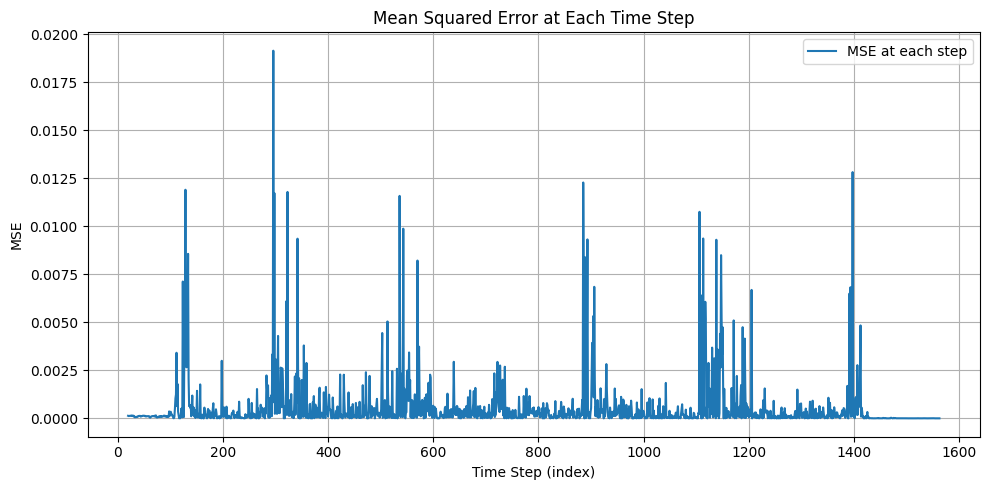

In [41]:

# Step 4: Plot MSE over time
plt.figure(figsize=(10, 5))
plt.plot(range(SEQ_LEN, SEQ_LEN + len(mse_each_step)), mse_each_step, label='MSE at each step')

plt.xlabel('Time Step (index)')
plt.ylabel('MSE')
plt.title('Mean Squared Error at Each Time Step')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

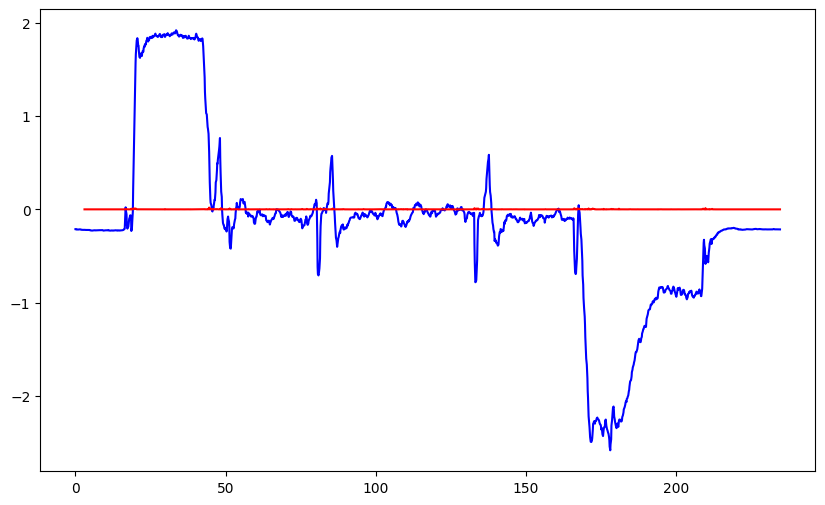

In [43]:
#plot velocity_z component of the df_test on top of mse values for each time step:
plt.figure(figsize=(10, 6))
plt.plot(test_df['time'], df_test['velocity_z'], label='Actual', color='blue')
plt.plot(test_df['time'][SEQ_LEN:], mse_each_step, label='MSE', color='red')
plt.show()



Index(['flight_id', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'payload', 'speed', 'altitude'],
      dtype='object')

## Generating Action vs State Features:


In [3]:
df=pd.read_csv('full_df.csv')
df.columns

Index(['flight_id', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'payload', 'speed', 'altitude'],
      dtype='object')

In [6]:
from scipy.spatial.transform import Rotation as R

def compute_euler_angles(df):
    r = R.from_quat(df[['orientation_x', 'orientation_y', 'orientation_z', 'orientation_w']].values)
    euler = r.as_euler('xyz', degrees=False)  # radians
    df['roll'], df['pitch'], df['yaw'] = euler[:, 0], euler[:, 1], euler[:, 2]
    return df

In [7]:
compute_euler_angles(df)

,flight_id,time,wind_speed,wind_angle,battery_voltage,battery_current,position_x,position_y,position_z,orientation_x,...,angular_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z,payload,speed,altitude,roll,pitch,yaw
0,188,0.00,0.3,219.0,24.763060,-0.047711,-79.782822,40.458932,269.009360,-0.003686,...,0.006308,-0.199847,0.047808,-9.807822,0.0,4.0,100,-0.017459,-0.006886,-3.085546
1,188,0.10,0.3,213.0,24.751791,-0.071566,-79.782822,40.458932,269.001628,-0.003696,...,0.003688,-0.197228,0.036270,-9.810002,0.0,4.0,100,-0.017463,-0.006905,-3.085499
2,188,0.20,0.3,211.0,24.751791,-0.055662,-79.782822,40.458932,268.994049,-0.003673,...,0.006240,-0.198856,0.049134,-9.808022,0.0,4.0,100,-0.017459,-0.006859,-3.085419
3,188,0.40,0.3,206.0,24.750538,-0.071566,-79.782822,40.458932,268.994294,-0.003662,...,-0.003805,-0.198083,0.043433,-9.809176,0.0,4.0,100,-0.017436,-0.006836,-3.085367
4,188,0.60,0.3,202.0,24.755547,-0.055662,-79.782822,40.458932,268.987012,-0.003640,...,0.004757,-0.196509,0.032449,-9.810179,0.0,4.0,100,-0.017501,-0.006791,-3.085319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54201,92,175.30,1.6,205.0,22.589499,0.063614,-79.782776,40.459016,266.461147,0.022538,...,-0.002165,0.177342,-0.573827,-9.790430,500.0,12.0,75,0.014733,0.056321,-1.260063
54202,92,175.40,1.5,203.0,22.586994,0.055662,-79.782776,40.459016,266.455180,0.022557,...,0.001913,0.177811,-0.575692,-9.793555,500.0,12.0,75,0.014766,0.056340,-1.260056
54203,92,175.60,1.5,209.0,22.583239,0.055662,-79.782776,40.459016,266.452046,0.022571,...,0.003508,0.178243,-0.576529,-9.793402,500.0,12.0,75,0.014796,0.056345,-1.260106
54204,92,175.70,1.4,210.0,22.580734,0.039759,-79.782776,40.459016,266.453643,0.022588,...,-0.008027,0.173612,-0.570025,-9.792116,500.0,12.0,75,0.014832,0.056350,-1.260126


In [8]:
#Also compute throttle using velocity and accelerationg:
g = 9.81
df['throttle_proxy'] = df['linear_acceleration_z'] + g

In [13]:
df.head(2)
df.to_csv("full_df_actions.csv", index=False)

In [6]:
!pip install gym



# Step1: Supervised Learning:
 Learning from data:a kind of multi model regression
 We will then use the trained weights in the RL model

  df=pd.read_csv('full_df_actions.csv')

In [7]:
#connect to drive:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Drone\ Stabilization\ GNN+Deep\ RL



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Drone Stabilization GNN+Deep RL


In [8]:
#import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# MODELS:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader, Dataset
import torch.nn.functional as F


In [8]:
os.getcwd()

'/content/drive/MyDrive/Drone Stabilization GNN+Deep RL'

In [4]:

df=pd.read_csv('full_df_actions.csv')

In [22]:
df.columns

Index(['flight_id', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'payload', 'speed', 'altitude', 'roll',
       'pitch', 'yaw', 'throttle_proxy'],
      dtype='object')

In [5]:
state_features = [
    'wind_speed','wind_angle',
    'position_x','position_y','position_z',
    'velocity_x','velocity_y','velocity_z',
    'angular_x','angular_y','angular_z',
    'linear_acceleration_x','linear_acceleration_y',
    'payload','speed','altitude'
]
action_targets = ['roll','pitch','yaw','throttle_proxy']

In [7]:
df[state_features].describe()

,wind_speed,wind_angle,position_x,position_y,position_z,velocity_x,velocity_y,velocity_z,angular_x,angular_y,angular_z,linear_acceleration_x,linear_acceleration_y,payload,speed,altitude
count,54206.000000,54206.000000,54206.000000,54206.000000,54206.000000,54206.000000,54206.000000,54206.000000,54206.000000,5.420600e+04,54206.000000,54206.000000,54206.000000,54206.000000,54206.000000,54206.000000
mean,4.345296,165.365218,-79.782461,40.458930,301.444530,-0.194758,2.448602,0.323511,-0.001509,-5.868106e-04,0.034035,-0.357133,-0.008172,251.867874,7.596576,58.690459
std,3.462546,100.124681,0.000453,0.000385,32.119901,0.459105,3.368067,1.435087,0.124818,1.857780e-01,0.264207,0.763144,0.387397,207.478187,2.855076,28.998525
min,0.000000,0.000000,-79.782891,40.457956,261.358347,-5.628508,-4.230620,-4.015751,-1.844877,-3.619476e+00,-1.794828,-4.314568,-2.531106,0.000000,4.000000,25.000000
25%,1.500000,76.000000,-79.782777,40.458928,272.967091,-0.350319,0.003552,-0.157393,-0.046939,-4.181535e-02,-0.042848,-0.781500,-0.201382,0.000000,4.000000,25.000000
50%,3.200000,173.000000,-79.782748,40.459034,291.663925,-0.039123,0.089855,0.045046,-0.000423,7.433984e-07,0.001480,-0.061415,-0.013014,250.000000,8.000000,50.000000
75%,6.600000,240.000000,-79.782282,40.459072,320.338779,0.008314,4.211643,0.912147,0.042809,4.275799e-02,0.057685,0.162787,0.184192,500.000000,10.000000,75.000000
max,17.100000,359.000000,-79.781261,40.459682,376.188721,2.575932,12.436134,5.842570,3.022839,2.833664e+00,2.148074,3.540460,3.656778,500.000000,12.000000,100.000000


### MODEL 1

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ------------------------------------------------------------------
# 1.  CONFIG
# ------------------------------------------------------------------
BATCH_SIZE     = 256
LR             = 1e-3
WEIGHT_DECAY   = 1e-4          # L2 regularisation strength
NUM_EPOCHS     = 200
THROTTLE_W     = 2.0           # <-- emphasise throttle_proxy
PITCH_W        = 3.0
YAW_W          = 1.5
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'

state_features = [
    'wind_speed','wind_angle',
    'position_x','position_y','position_z',
    'velocity_x','velocity_y','velocity_z',
    'angular_x','angular_y','angular_z',
    'linear_acceleration_x','linear_acceleration_y',
    'payload','speed','altitude'
]
action_targets = ['roll','pitch','yaw','throttle_proxy']
n_state   = len(state_features)
n_action  = len(action_targets)

# ------------------------------------------------------------------
# 2.  DATA  (assumes df already loaded)
# ------------------------------------------------------------------
X = torch.tensor(df[state_features].values,  dtype=torch.float32)
y = torch.tensor(df[action_targets].values, dtype=torch.float32)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True)


# Fit scaler on train, apply to both train and test
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# (Optional) Scale y as well if action targets have very different ranges
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

import joblib
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")


# Convert to torch tensors
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_torch = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_torch  = torch.tensor(y_test_scaled,  dtype=torch.float32)


train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_torch, y_train_torch),
    batch_size=BATCH_SIZE, shuffle=True)

test_loader  = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_test_torch,  y_test_torch),
    batch_size=BATCH_SIZE, shuffle=False)

# ------------------------------------------------------------------
# 3.  MODEL
# ------------------------------------------------------------------
class PolicyNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.net(x)

model = PolicyNet(input_dim=n_state, output_dim=n_action).to(DEVICE)

# ------------------------------------------------------------------
# 4.  LOSS  (weighted per-action MSE)
# ------------------------------------------------------------------
# create a weight vector: [1, 1, 1, THROTTLE_W]
loss_weights = torch.tensor(
    [1.0, PITCH_W, YAW_W, THROTTLE_W], dtype=torch.float32, device=DEVICE
)

def weighted_mse(outputs, targets):
    # shape: (batch, action_dim)
    mse_per_dim = (outputs - targets).pow(2)
    weighted    = mse_per_dim * loss_weights
    return weighted.mean()

# ------------------------------------------------------------------
# 5.  OPTIMISER  (Adam + L2 weight decay)
# ------------------------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ------------------------------------------------------------------
# 6.  TRAIN LOOP
# ------------------------------------------------------------------
best_loss = float('inf')
for epoch in range(1, NUM_EPOCHS + 1):
    # ---- train ----------------------------------------------------
    model.train()
    running_train_loss = 0.0
    for states, actions in train_loader:
        states, actions = states.to(DEVICE), actions.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(states)
        loss    = weighted_mse(outputs, actions)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * states.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)

    # ---- evaluate -------------------------------------------------
    model.eval()
    running_test_loss = 0.0
    # collect preds/targets for per-action MSE
    preds_list, targs_list = [], []

    with torch.no_grad():
        for states, actions in test_loader:
            states, actions = states.to(DEVICE), actions.to(DEVICE)
            outputs = model(states)

            loss = weighted_mse(outputs, actions)
            running_test_loss += loss.item() * states.size(0)

            preds_list.append(outputs.cpu().numpy())
            targs_list.append(actions.cpu().numpy())

    test_loss = running_test_loss / len(test_loader.dataset)

    # # ---- per-action MSE ------------------------------------------
    preds = np.concatenate(preds_list, axis=0)
    targs = np.concatenate(targs_list, axis=0)
    per_action_mse = np.mean((preds - targs) ** 2, axis=0)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} "
              f"Train {train_loss:.4f}  Test {test_loss:.4f}")
        for i, act in enumerate(action_targets):
            print(f"   MSE {act:15s}: {per_action_mse[i]:.4f}")

    # ---- checkpoint ---------------------------------------------
    if test_loss < best_loss:
        epoch_best=epoch
        best_loss = test_loss
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss'          : train_loss,
            'test_loss'           : test_loss,
            # 'per_action_mse'      : per_action_mse,
        }, 'best_model.pth')
print(f"✅ New best model saved at epoch {epoch_best} (Test Loss: {best_loss:.4f})")

Epoch   1/200 Train 1.1354  Test 0.9415
   MSE roll           : 0.2523
   MSE pitch          : 0.3177
   MSE yaw            : 0.4572
   MSE throttle_proxy : 0.9373
Epoch  10/200 Train 0.6328  Test 0.6604
   MSE roll           : 0.1083
   MSE pitch          : 0.2341
   MSE yaw            : 0.1682
   MSE throttle_proxy : 0.7892
Epoch  20/200 Train 0.5146  Test 0.5770
   MSE roll           : 0.0913
   MSE pitch          : 0.2167
   MSE yaw            : 0.1324
   MSE throttle_proxy : 0.6840
Epoch  30/200 Train 0.4590  Test 0.5271
   MSE roll           : 0.0823
   MSE pitch          : 0.1922
   MSE yaw            : 0.1137
   MSE throttle_proxy : 0.6394
Epoch  40/200 Train 0.4265  Test 0.5055
   MSE roll           : 0.0762
   MSE pitch          : 0.1875
   MSE yaw            : 0.1057
   MSE throttle_proxy : 0.6124
Epoch  50/200 Train 0.4064  Test 0.4910
   MSE roll           : 0.0721
   MSE pitch          : 0.1852
   MSE yaw            : 0.1011
   MSE throttle_proxy : 0.5924
Epoch  60/200 Tr

In [10]:
import torch, numpy as np, torch.nn as nn, torch.optim as optim

# ------------------------------------------------------------
# CONFIG ── tweak as you like
# ------------------------------------------------------------
ADD_EPOCHS   = 300          # how many *extra* epochs to try
PATIENCE     = 25           # stop if no improvement for this many epochs
MIN_DELTA    = 1e-4         # improvement threshold
THROTTLE_W   = 1        # keep your throttle weight
YAW_W        = 1
PITCH_W      = 2
WEIGHT_DECAY = 1e-4
LR           = 1e-3
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

# ────────────────────────────────────────────────────────────
# 1. Re-create model & optimizer exactly as before
# ────────────────────────────────────────────────────────────
class PolicyNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x): return self.net(x)

n_state   = len(state_features)      # from your earlier code
n_action  = len(action_targets)
model     = PolicyNet(n_state, n_action).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# weighted loss
#ADDED WEIGHT ON YAW:
w = torch.tensor([1,1,YAW_W,THROTTLE_W], dtype=torch.float32, device=DEVICE)
def weighted_mse(o,t): return ((o-t).pow(2)*w).mean()

# ────────────────────────────────────────────────────────────
# 2. Load checkpoint
# ────────────────────────────────────────────────────────────
ckpt = torch.load("best_model.pth", map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])
start_epoch = ckpt['epoch'] + 1
best_loss   = ckpt['test_loss']
print(f"✔️  Reloaded checkpoint at epoch {ckpt['epoch']}  (best test loss = {best_loss:.4f})")

# ────────────────────────────────────────────────────────────
# 3. Resume training with EARLY STOPPING
# ────────────────────────────────────────────────────────────
epochs_no_improve = 0
for epoch in range(start_epoch, start_epoch + ADD_EPOCHS):
    # ---- TRAIN ---------------------------------------------------
    model.train()
    train_sum = 0
    for s,a in train_loader:
        s,a = s.to(DEVICE), a.to(DEVICE)
        optimizer.zero_grad()
        loss = weighted_mse(model(s), a)
        loss.backward(); optimizer.step()
        train_sum += loss.item()*s.size(0)
    train_loss = train_sum / len(train_loader.dataset)

    # ---- EVAL ----------------------------------------------------
    model.eval()
    test_sum, preds, targs = 0, [], []
    with torch.no_grad():
        for s,a in test_loader:
            s,a = s.to(DEVICE), a.to(DEVICE)
            out = model(s)
            test_sum += weighted_mse(out,a).item()*s.size(0)
            preds.append(out.cpu().numpy()); targs.append(a.cpu().numpy())
    test_loss = test_sum / len(test_loader.dataset)

    # ---- per-action report every 10 epochs -----------------------
    if epoch % 10 == 0:
        pa_mse = np.mean((np.vstack(preds)-np.vstack(targs))**2,0)
        print(f"Epoch {epoch:3d}  Train {train_loss:.4f}  Test {test_loss:.4f}  "
              f"Δ={best_loss-test_loss:+.5f}")
        for i,a in enumerate(action_targets):
            print(f"   {a:15s} MSE: {pa_mse[i]:.4f}")

    # ---- EARLY-STOP LOGIC ---------------------------------------
    if test_loss < best_loss - MIN_DELTA:
        best_loss = test_loss
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_loss': best_loss
        }, 'best_model.pth')
        print(f"✅  New best model saved at epoch {epoch} (Test {best_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"⏹️  Early stopping at epoch {epoch}. "
                  f"No improvement for {PATIENCE} consecutive epochs.\n"f'Best MSE= {best_loss}')
            break

✔️  Reloaded checkpoint at epoch 205  (best test loss = 0.2037)


NameError: name 'train_loader' is not defined

### Cheking Prediction and Test Resutls:

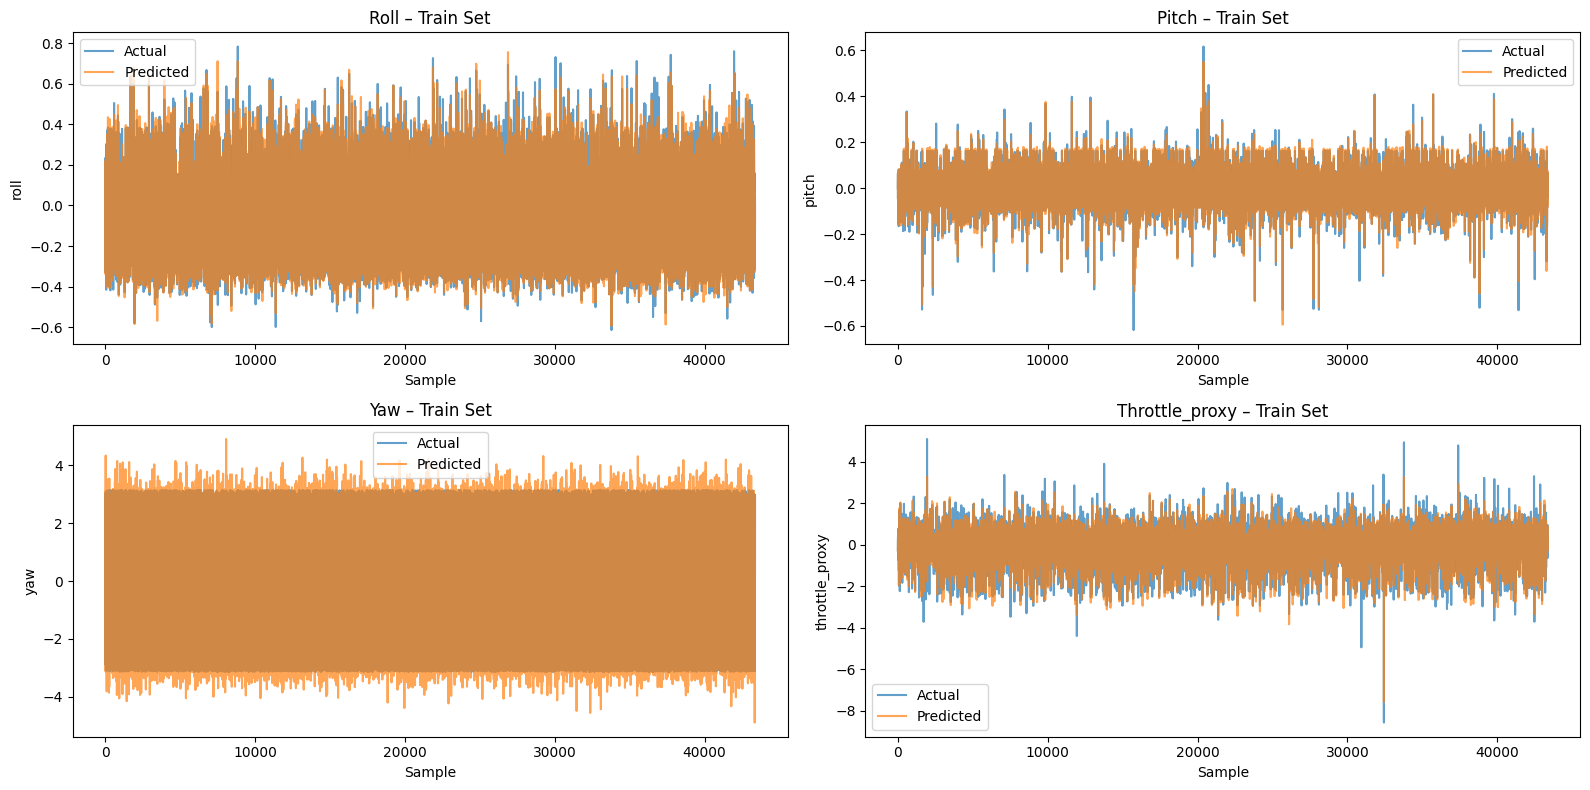

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------------------------------------
# 1️⃣  Put model in eval mode and get predictions in one shot
# -------------------------------------------------------------
model.eval()
with torch.no_grad():
    # X_train_scaled is the numpy array AFTER StandardScaler
    preds_scaled = model(
        torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
    ).cpu().numpy()

# -------------------------------------------------------------
# 2️⃣  Inverse-transform to physical units
# -------------------------------------------------------------
preds_orig   = scaler_y.inverse_transform(preds_scaled)          # shape (N,4)
actual_orig  = scaler_y.inverse_transform(y_train_scaled)        # or use y_train

action_names = ['roll', 'pitch', 'yaw', 'throttle_proxy']

# -------------------------------------------------------------
# 3️⃣  Plot
# -------------------------------------------------------------
plt.figure(figsize=(16, 8))
for i, name in enumerate(action_names):
    plt.subplot(2, 2, i + 1)
    plt.plot(actual_orig[:, i],  label='Actual',    alpha=0.7)
    plt.plot(preds_orig[:,  i],  label='Predicted', alpha=0.7)
    plt.title(f'{name.capitalize()} – Train Set')
    plt.xlabel('Sample')
    plt.ylabel(name)
    plt.legend()

plt.tight_layout()
plt.show()

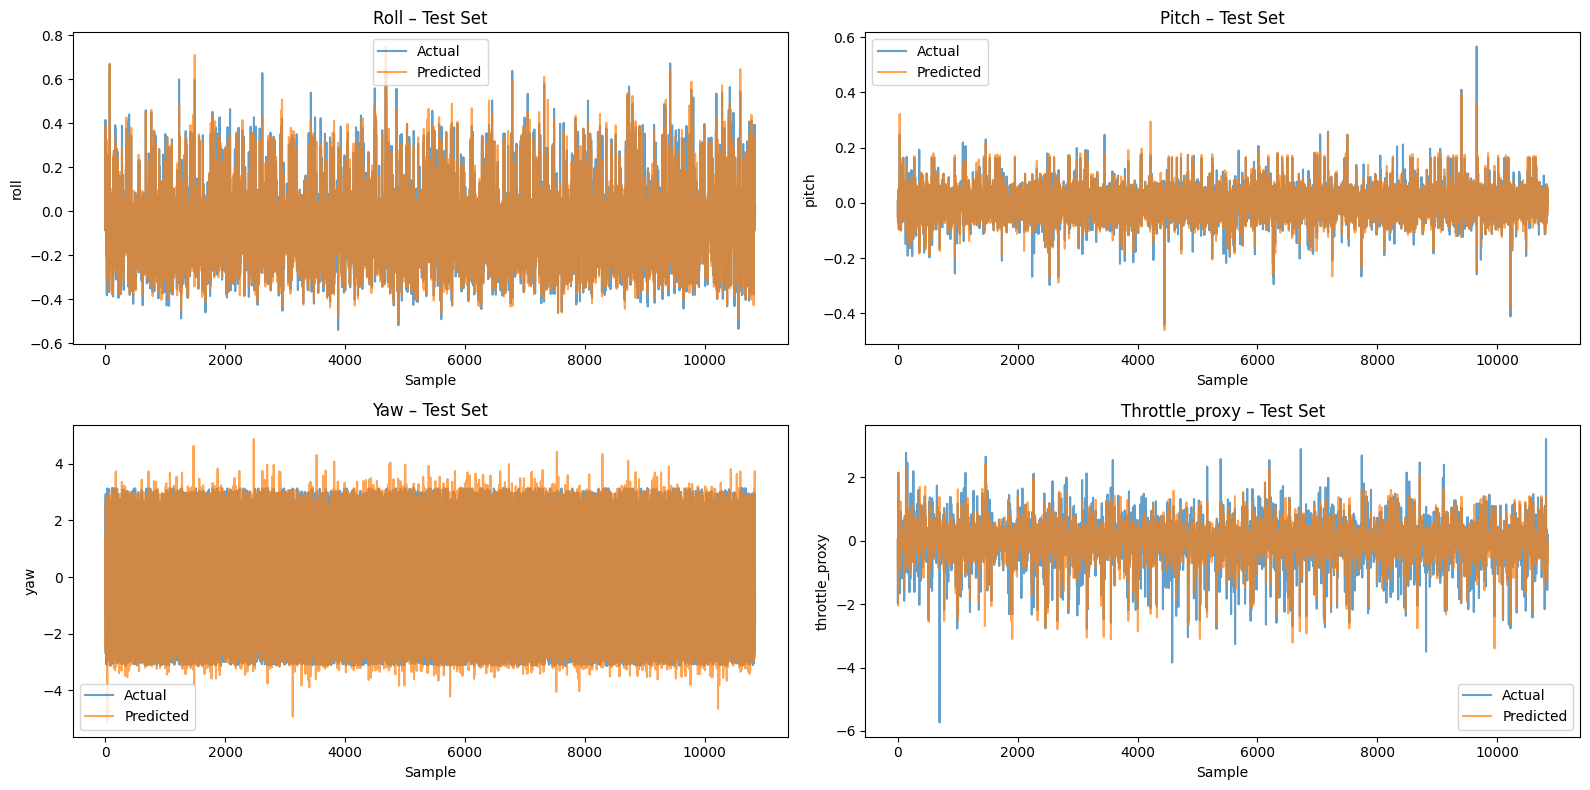

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------------------------------------
# 1️⃣  Put model in eval mode and get predictions in one shot
# -------------------------------------------------------------
model.eval()
with torch.no_grad():
    # X_train_scaled is the numpy array AFTER StandardScaler
    preds_scaled = model(
        torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
    ).cpu().numpy()

# -------------------------------------------------------------
# 2️⃣  Inverse-transform to physical units
# -------------------------------------------------------------
preds_orig   = scaler_y.inverse_transform(preds_scaled)          # shape (N,4)
actual_orig  = scaler_y.inverse_transform(y_test_scaled)        # or use y_train

action_names = ['roll', 'pitch', 'yaw', 'throttle_proxy']

# -------------------------------------------------------------
# 3️⃣  Plot
# -------------------------------------------------------------
plt.figure(figsize=(16, 8))
for i, name in enumerate(action_names):
    plt.subplot(2, 2, i + 1)
    plt.plot(actual_orig[:, i],  label='Actual',    alpha=0.7)
    plt.plot(preds_orig[:,  i],  label='Predicted', alpha=0.7)
    plt.title(f'{name.capitalize()} – Test Set')
    plt.xlabel('Sample')
    plt.ylabel(name)
    plt.legend()

plt.tight_layout()
plt.show()

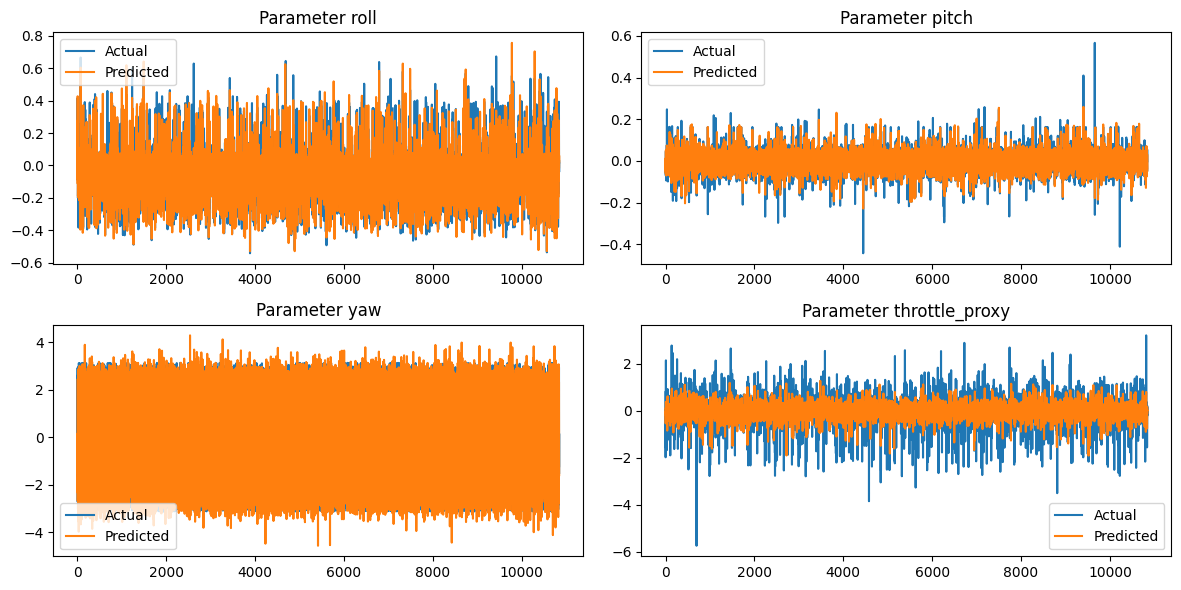

In [23]:
import matplotlib.pyplot as plt

# Get predictions in original scale
y_pred_scaled = model(X_test_t).detach().numpy()
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# Get actual y_test in original scale
y_actual = y_scaler.inverse_transform(y_test_scaled)

# Plot
plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(y_actual[:, i], label='Actual')
    plt.plot(y_pred[:, i], label='Predicted')
    plt.title(f'Parameter {action_targets[i]}')
    plt.legend()
plt.tight_layout()
plt.show()


In [5]:
df.head()

,flight_id,time,wind_speed,wind_angle,battery_voltage,battery_current,position_x,position_y,position_z,orientation_x,...,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z,payload,speed,altitude,roll,pitch,yaw,throttle_proxy
0,188,0.0,0.3,219.0,24.763060,-0.047711,-79.782822,40.458932,269.009360,-0.003686,...,-0.199847,0.047808,-9.807822,0.0,4.0,100,-0.017459,-0.006886,-3.085546,0.002178
1,188,0.1,0.3,213.0,24.751791,-0.071566,-79.782822,40.458932,269.001628,-0.003696,...,-0.197228,0.036270,-9.810002,0.0,4.0,100,-0.017463,-0.006905,-3.085499,-0.000002
2,188,0.2,0.3,211.0,24.751791,-0.055662,-79.782822,40.458932,268.994049,-0.003673,...,-0.198856,0.049134,-9.808022,0.0,4.0,100,-0.017459,-0.006859,-3.085419,0.001978
3,188,0.4,0.3,206.0,24.750538,-0.071566,-79.782822,40.458932,268.994294,-0.003662,...,-0.198083,0.043433,-9.809176,0.0,4.0,100,-0.017436,-0.006836,-3.085367,0.000824
4,188,0.6,0.3,202.0,24.755547,-0.055662,-79.782822,40.458932,268.987012,-0.003640,...,-0.196509,0.032449,-9.810179,0.0,4.0,100,-0.017501,-0.006791,-3.085319,-0.000179


# STEP2: GYM_Pybullet-Drones:

In [6]:
os.getcwd()

'/content/drive/MyDrive/Drone Stabilization GNN+Deep RL'

In [7]:
!apt-get install -y xvfb
!pip install pybullet
!pip install gym
!git clone https://github.com/utiasDSL/gym-pybullet-drones.git
%cd gym-pybullet-drones
!pip install -e .
%cd ..

/content/drive/MyDrive/Drone Stabilization GNN+Deep RL/gym-pybullet-drones
Obtaining file:///content/drive/MyDrive/Drone%20Stabilization%20GNN%2BDeep%20RL/gym-pybullet-drones
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61

/content/drive/MyDrive/Drone Stabilization GNN+Deep RL


In [1]:
import gymnasium as gym
import gym_pybullet_drones

# Manually register the environment if needed
from gymnasium.envs.registration import register

register(
    id='hover-aviary-v0',
    entry_point='gym_pybullet_drones.envs.HoverAviary:HoverAviary',
)

env = gym.make('hover-aviary-v0')
obs, info = env.reset()
print("Gymnasium ID works! Observation:", obs)

/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment hover-aviary-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Gymnasium ID works! Observation: [[ 0.      0.      0.1125  0.     -0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.     

/usr/local/lib/python3.11/dist-packages/gymnasium/utils/passive_env_checker.py:135: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


# RL Training:


In [11]:
os.getcwd()

'/content/drive/MyDrive/Drone Stabilization GNN+Deep RL'

In [2]:
# ---------------------------------------------------------------
# 0.  Imports & Versions
# ---------------------------------------------------------------
import gymnasium as gym                         # Gymnasium ≥0.28
import gym_pybullet_drones                      # insure package is installed
import joblib, numpy as np, torch
from gymnasium.envs.registration import register

from stable_baselines3 import PPO              # SB3 ≥ 2.3.2 supports Gymnasium
from stable_baselines3.common.torch_layers import MlpExtractor
from stable_baselines3.common.policies import ActorCriticPolicy


import joblib

try:
    from gym_pybullet_drones.envs.single_agent_rl.hover_aviary import HoverAviary
except ModuleNotFoundError:
    from gym_pybullet_drones.envs.HoverAviary import HoverAviary


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------------
# 1.  Environment wrapper that scales obs/actions
# ---------------------------------------------------------------
# ---------------------------------------------------------------
# 1.  Environment wrapper that scales obs/actions
#    (handles BOTH folder layouts)
# ---------------------------------------------------------------
import gymnasium as gym
import numpy as np
import joblib

try:  # ── NEW layout (after Aug-2023)
    from gym_pybullet_drones.envs.single_agent_rl.hover_aviary import HoverAviary
    print("✔ Using single_agent_rl.hover_aviary.HoverAviary")
except ModuleNotFoundError:
    from gym_pybullet_drones.envs.HoverAviary import HoverAviary
    print("✔ Using envs.HoverAviary (legacy layout)")


class ScaledAviary(gym.Wrapper):
    def __init__(self, gui=False):
        # instantiate base env (no GUI = faster)
        super().__init__(HoverAviary(gui=gui))
        self.scaler_X = joblib.load("scaler_X.pkl")
        self.scaler_y = joblib.load("scaler_y.pkl")

        obs_low  = -np.inf * np.ones(len(state_features), dtype=np.float32)
        obs_high =  np.inf * np.ones(len(state_features), dtype=np.float32)
        self.observation_space = gym.spaces.Box(obs_low, obs_high, dtype=np.float32)

        act_dim = len(action_targets)
        self.action_space = gym.spaces.Box(
        low = -1.0 * np.ones(act_dim, dtype=np.float32),
        high =  1.0 * np.ones(act_dim, dtype=np.float32),
        dtype=np.float32,
        )

    # Gymnasium uses observation() & action() hooks for wrappers
    def observation(self, obs_dict):
        vec = np.array([obs_dict[k] for k in state_features], dtype=np.float32)
        return self.scaler_X.transform(vec.reshape(1, -1)).squeeze()

    def action(self, act_scaled):
        act_real = self.scaler_y.inverse_transform(
            np.asarray(act_scaled).reshape(1, -1)).squeeze()
        return act_real

# ---------------------------------------------------------------
# 2.  Create & register scaled environment (Gymnasium style)
# ---------------------------------------------------------------
register(
    id="ScaledHoverAviary-v0",
    entry_point=lambda **kwargs: ScaledAviary(**kwargs),
    max_episode_steps=4000,
)

env = gym.make("ScaledHoverAviary-v0", gui=False)

# ---------------------------------------------------------------
# 3.  SB3 policy architecture identical to BC network (128→64→4)
# ---------------------------------------------------------------
class BCPolicy(ActorCriticPolicy):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)  # <-- no activation_fn/net_arch here!

    def _build_mlp_extractor(self) -> None:
        self.mlp_extractor = MlpExtractor(
            self.features_dim, net_arch=self.net_arch,
            activation_fn=self.activation_fn, device=self.device
        )

# ---------------------------------------------------------------
# 4.  Instantiate PPO (weights random for now)
# ---------------------------------------------------------------
policy_kwargs = dict(
    net_arch=dict(pi=[128, 64], vf=[128, 64]),  # policy and value function
    activation_fn=torch.nn.ReLU
)
ppo = PPO(
    BCPolicy,
    env,
    learning_rate=3e-4,
    batch_size=512,
    n_steps=2048,
    gamma=0.99,
    verbose=1,
    device=DEVICE,
    policy_kwargs=policy_kwargs,  # <-- add this!
)

# ---------------------------------------------------------------
# 5.  Load BC network & copy weights into PPO actor
# ---------------------------------------------------------------
class PolicyNet(torch.nn.Module):        # must match original BC class
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, 64),        torch.nn.ReLU(),
            torch.nn.Linear(64, output_dim)
        )
    def forward(self, x): return self.net(x)

bc_ckpt = torch.load("best_model.pth", map_location=DEVICE)
bc_net  = PolicyNet(len(state_features), len(action_targets)).to(DEVICE)
bc_net.load_state_dict(bc_ckpt["model_state_dict"])

def inject_weights(bc_net, ppo_policy):
    """
    Copy BC weights into the PPO actor network.
    Assumes identical hidden-layer sizes 128 → 64.
    """
    # --- 1️⃣  grab linear layers ---------------------------------
    bc_layers = [m for m in bc_net.net if isinstance(m, torch.nn.Linear)]
    # bc_layers = [in→128, 128→64, 64→4]

    pi_layers = [m for m in ppo_policy.mlp_extractor.policy_net
                 if isinstance(m, torch.nn.Linear)]
    # pi_layers = [in→128, 128→64]

    # --- 2️⃣  copy hidden layers ---------------------------------
    for bc_lin, pi_lin in zip(bc_layers[:-1], pi_layers):   # skip BC output
        pi_lin.weight.data.copy_(bc_lin.weight.data)
        pi_lin.bias.data.copy_(bc_lin.bias.data)

    # --- 3️⃣  copy BC *output* layer into PPO action_net ----------
    ppo_policy.action_net.weight.data.copy_(bc_layers[-1].weight.data)
    ppo_policy.action_net.bias.data.copy_(bc_layers[-1].bias.data)

inject_weights(bc_net, ppo.policy)
print("✅  Behavioural-cloning weights injected into PPO actor")

# ---------------------------------------------------------------
# 6.  RL Training
# ---------------------------------------------------------------
TOTAL_STEPS = 1_000_000       # 1 M steps; adjust to resources
ppo.learn(total_timesteps=TOTAL_STEPS)
ppo.save("ppo_finetuned_gymnasium")

# ---------------------------------------------------------------
# 7.  Quick evaluation with GUI
# ---------------------------------------------------------------
test_env = gym.make("ScaledHoverAviary-v0", gui=True)
obs, info = test_env.reset(seed=0)
terminated = truncated = False
while not (terminated or truncated):
    act, _ = ppo.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = test_env.step(act)

✔ Using envs.HoverAviary (legacy layout)
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


FileNotFoundError: [Errno 2] No such file or directory: 'scaler_X.pkl'

### Inspecting what HOVER_AVIARY PRODUCES:

In [22]:
env = HoverAviary(gui=False)
obs, _ = env.reset()
print("Raw obs shape:", obs.shape)
print("First 20 elements:", obs[:20])

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Raw obs shape: (1, 72)
First 20 elements: [[ 0.      0.      0.1125  0.     -0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.    

In [9]:
import torch
import torch.nn as nn

class PolicyNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)

In [10]:
# Set your device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Define input/output dims
input_dim = 16  # number of state_features
output_dim = 4  # number of action_targets

# Instantiate the model
model = PolicyNet(input_dim, output_dim).to(DEVICE)

# Load the checkpoint
checkpoint = torch.load("best_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()  # Set to evaluation mode

print("✅ Model loaded and ready for inference!")

✅ Model loaded and ready for inference!


In [11]:
import joblib
scaler_X = joblib.load("scaler_X.pkl")
scaler_y = joblib.load("scaler_y.pkl")

### APPLYING the HOVER simulation and Episode Parameters:

In [16]:
import gymnasium as gym
import numpy as np

class ContextualAviaryWrapper(gym.Wrapper):
    def __init__(self, env, scaler_X):
        super().__init__(env)
        self.scaler_X = scaler_X
        self.context = None
        # --- tell Gym/SB3 the new obs shape ---
        obs_dim = 16
        self.observation_space = gym.spaces.Box(
            low  = -5.0,           # any finite bounds are fine
            high = 5.0,
            shape=(obs_dim,),
            dtype=np.float32
        )

        # keep the original action_space
        self.action_space = env.action_space

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        # Sample context features ONCE per episode
        self.context = {
            'wind_speed': np.random.uniform(0.0, 17.1),
            'wind_angle': np.random.uniform(0.0, 359.0),
            'payload':    np.random.uniform(0.0, 500.0),
            'speed':      np.random.uniform(4.0, 12.0),
            'altitude':   np.random.uniform(25.0, 100.0),
            # Optionally, sample linear_acceleration_x/y if you want
        }
        return self._build_obs(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._build_obs(obs), reward, terminated, truncated, info

    def _build_obs(self, hover_obs):
        # hover_obs: (72,) or (1, 72)
        if hover_obs.ndim == 2:
            hover_obs = hover_obs[0]
        obs = np.array([
            self.context['wind_speed'],
            self.context['wind_angle'],
            hover_obs[0],  # position_x
            hover_obs[1],  # position_y
            hover_obs[2],  # position_z
            hover_obs[6],  # velocity_x
            hover_obs[7],  # velocity_y
            hover_obs[8],  # velocity_z
            hover_obs[9],  # angular_x
            hover_obs[10], # angular_y
            hover_obs[11], # angular_z
            0.0,           # linear_acceleration_x (or sample)
            0.0,           # linear_acceleration_y (or sample)
            self.context['payload'],
            self.context['speed'],
            self.context['altitude']
        ], dtype=np.float32)
        obs_scaled = self.scaler_X.transform(obs.reshape(1, -1)).squeeze().astype(np.float32)
        return obs_scaled

In [17]:
env = HoverAviary(gui=False)
wrapped_env = ContextualAviaryWrapper(env, scaler_X)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


In [21]:
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import MlpExtractor
import torch

class BCPolicy(ActorCriticPolicy):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    def _build_mlp_extractor(self) -> None:
        self.mlp_extractor = MlpExtractor(
            self.features_dim, net_arch=self.net_arch,
            activation_fn=self.activation_fn, device=self.device
        )

policy_kwargs = dict(
    net_arch=dict(pi=[128, 64], vf=[128, 64]),
    activation_fn=torch.nn.ReLU
)

ppo = PPO(
    BCPolicy,
    wrapped_env,
    learning_rate=3e-4,
    batch_size=512,
    n_steps=2048,
    gamma=0.99,
    verbose=1,
    device="cuda" if torch.cuda.is_available() else "cpu",
    policy_kwargs=policy_kwargs,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [22]:
def inject_weights(bc_net, ppo_policy):
    bc_layers = [m for m in bc_net.net if isinstance(m, torch.nn.Linear)]
    pi_layers = [m for m in ppo_policy.mlp_extractor.policy_net if isinstance(m, torch.nn.Linear)]
    for bc_lin, pi_lin in zip(bc_layers[:-1], pi_layers):
        pi_lin.weight.data.copy_(bc_lin.weight.data)
        pi_lin.bias.data.copy_(bc_lin.bias.data)
    ppo_policy.action_net.weight.data.copy_(bc_layers[-1].weight.data)
    ppo_policy.action_net.bias.data.copy_(bc_layers[-1].bias.data)

inject_weights(model, ppo.policy)
print("✅ BC weights injected into PPO actor")

✅ BC weights injected into PPO actor


In [23]:
obs, _ = wrapped_env.reset()
print(obs.shape)                   # (16,)
print(wrapped_env.observation_space.shape)  # (16,)

(16,)
(16,)


In [ ]:
test_env = ContextualAviaryWrapper(HoverAviary(gui=True), scaler_X)
obs, info = test_env.reset(seed=0)
terminated = truncated = False
while not (terminated or truncated):
    action, _ = ppo.predict(obs, deterministic=True)   # BC-initialised policy
    obs, reward, terminated, truncated, info = test_env.step(action)